# Multi-agents Classifier

In [5]:
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import dump

# ---- paths ----
multi_base = Path("/Users/azza/Desktop/AI agents/ml/multi_agent_dataset/")
single_base = Path("/Users/azza/Desktop/AI agents/ml/single_agent_dataset/")

multi_path = multi_base / "weather_all.npz"
single_path = single_base / "weather_all.npz"

# ---- load multi-agent data ----
dm = np.load(multi_path)
X_multi = dm["dataset"]
y_multi = dm["label"].astype(int)

# ---- load single-agent data ----
ds = np.load(single_path)
X_single = ds["dataset"]
y_single = ds["label"].astype(int)

print("Loaded multi:", multi_path)
print("X_multi:", X_multi.shape, X_multi.dtype)
print("y_multi:", y_multi.shape, y_multi.dtype)

print("\nLoaded single:", single_path)
print("X_single:", X_single.shape, X_single.dtype)
print("y_single:", y_single.shape, y_single.dtype)

# ---- flatten ----
X_multi = X_multi.reshape(X_multi.shape[0], -1)
X_single = X_single.reshape(X_single.shape[0], -1)

# ---- create six-class labels ----
# single: 0, 1, 2
# multi:  3, 4, 5
y_single_joint = y_single
y_multi_joint = y_multi + 3

# ---- combine datasets ----
X = np.concatenate([X_single, X_multi], axis=0)
y = np.concatenate([y_single_joint, y_multi_joint], axis=0)

print("\nCombined X:", X.shape)
print("Combined y:", y.shape)
print("Class counts:", np.bincount(y))

# ---- class names ----
class_names = [
    "Single-OpenAI",
    "Single-Gemini",
    "Single-DeepSeek",
    "Multi-OpenAI",
    "Multi-Gemini",
    "Multi-DeepSeek"
]

# ---- train/test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---- model ----
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# ---- train ----
rf.fit(X_train, y_train)

# ---- evaluate ----
pred = rf.predict(X_test)

acc = accuracy_score(y_test, pred)
print("\nAccuracy:", acc)

print("\nConfusion matrix:\n")
print(confusion_matrix(y_test, pred))

print("\nClassification report:\n")
print(classification_report(y_test, pred, target_names=class_names))

# ---- save model ----
dump(rf, "rf_weather_six_class_single_multi.joblib")

Loaded multi: /Users/azza/Desktop/AI agents/ml/multi_agent_dataset/weather_all.npz
X_multi: (619, 7200) float32
y_multi: (619,) int64

Loaded single: /Users/azza/Desktop/AI agents/ml/single_agent_dataset/weather_all.npz
X_single: (720, 7200) float32
y_single: (720,) int64

Combined X: (1339, 7200)
Combined y: (1339,)
Class counts: [240 240 240 236 184 199]

Accuracy: 0.9365671641791045

Confusion matrix:

[[44  0  1  0  0  3]
 [ 3 40  4  0  0  1]
 [ 0  0 44  0  0  4]
 [ 0  0  0 47  0  0]
 [ 0  0  0  0 37  0]
 [ 0  0  1  0  0 39]]

Classification report:

                 precision    recall  f1-score   support

  Single-OpenAI       0.94      0.92      0.93        48
  Single-Gemini       1.00      0.83      0.91        48
Single-DeepSeek       0.88      0.92      0.90        48
   Multi-OpenAI       1.00      1.00      1.00        47
   Multi-Gemini       1.00      1.00      1.00        37
 Multi-DeepSeek       0.83      0.97      0.90        40

       accuracy                       

['rf_weather_six_class_single_multi.joblib']

In [9]:
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import dump

# ---- paths ----
multi_base = Path("/Users/azza/Desktop/AI agents/ml/multi_agent_dataset/")
single_base = Path("/Users/azza/Desktop/AI agents/ml/single_agent_dataset/")

multi_path = multi_base / "no-tools_all.npz"
single_path = single_base / "no-tools_all.npz"

# ---- load multi-agent data ----
dm = np.load(multi_path)
X_multi = dm["dataset"]
y_multi = dm["label"].astype(int)

# ---- load single-agent data ----
ds = np.load(single_path)
X_single = ds["dataset"]
y_single = ds["label"].astype(int)

print("Loaded multi:", multi_path)
print("X_multi:", X_multi.shape, X_multi.dtype)
print("y_multi:", y_multi.shape, y_multi.dtype)

print("\nLoaded single:", single_path)
print("X_single:", X_single.shape, X_single.dtype)
print("y_single:", y_single.shape, y_single.dtype)

# ---- flatten ----
X_multi = X_multi.reshape(X_multi.shape[0], -1)
X_single = X_single.reshape(X_single.shape[0], -1)

# ---- create six-class labels ----
# single: 0, 1, 2
# multi:  3, 4, 5
y_single_joint = y_single
y_multi_joint = y_multi + 3

# ---- combine datasets ----
X = np.concatenate([X_single, X_multi], axis=0)
y = np.concatenate([y_single_joint, y_multi_joint], axis=0)

print("\nCombined X:", X.shape)
print("Combined y:", y.shape)
print("Class counts:", np.bincount(y))

# ---- class names ----
class_names = [
    "Single-OpenAI",
    "Single-Gemini",
    "Single-DeepSeek",
    "Multi-OpenAI",
    "Multi-Gemini",
    "Multi-DeepSeek"
]

# ---- train/test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---- model ----
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# ---- train ----
rf.fit(X_train, y_train)

# ---- evaluate ----
pred = rf.predict(X_test)

acc = accuracy_score(y_test, pred)
print("\nAccuracy:", acc)

print("\nConfusion matrix:\n")
print(confusion_matrix(y_test, pred))

print("\nClassification report:\n")
print(classification_report(y_test, pred, target_names=class_names))

# ---- save model ----
dump(rf, "rf_no-tools_six_class_single_multi.joblib")

Loaded multi: /Users/azza/Desktop/AI agents/ml/multi_agent_dataset/no-tools_all.npz
X_multi: (580, 7200) float32
y_multi: (580,) int64

Loaded single: /Users/azza/Desktop/AI agents/ml/single_agent_dataset/no-tools_all.npz
X_single: (720, 7200) float32
y_single: (720,) int64

Combined X: (1300, 7200)
Combined y: (1300,)
Class counts: [240 240 240 170 195 215]

Accuracy: 0.9115384615384615

Confusion matrix:

[[46  0  0  2  0  0]
 [ 0 48  0  0  0  0]
 [ 0  1 45  0  0  2]
 [ 4  1  0 29  0  0]
 [ 0  0  0  0 39  0]
 [ 1  3  9  0  0 30]]

Classification report:

                 precision    recall  f1-score   support

  Single-OpenAI       0.90      0.96      0.93        48
  Single-Gemini       0.91      1.00      0.95        48
Single-DeepSeek       0.83      0.94      0.88        48
   Multi-OpenAI       0.94      0.85      0.89        34
   Multi-Gemini       1.00      1.00      1.00        39
 Multi-DeepSeek       0.94      0.70      0.80        43

       accuracy                     

['rf_no-tools_six_class_single_multi.joblib']

In [7]:
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import dump

# ---- paths ----
multi_base = Path("/Users/azza/Desktop/AI agents/ml/multi_agent_dataset/")
single_base = Path("/Users/azza/Desktop/AI agents/ml/single_agent_dataset/")

multi_path = multi_base / "research_all.npz"
single_path = single_base / "research_all.npz"

# ---- load multi-agent data ----
dm = np.load(multi_path)
X_multi = dm["dataset"]
y_multi = dm["label"].astype(int)

# ---- load single-agent data ----
ds = np.load(single_path)
X_single = ds["dataset"]
y_single = ds["label"].astype(int)

print("Loaded multi:", multi_path)
print("X_multi:", X_multi.shape, X_multi.dtype)
print("y_multi:", y_multi.shape, y_multi.dtype)

print("\nLoaded single:", single_path)
print("X_single:", X_single.shape, X_single.dtype)
print("y_single:", y_single.shape, y_single.dtype)

# ---- flatten ----
X_multi = X_multi.reshape(X_multi.shape[0], -1)
X_single = X_single.reshape(X_single.shape[0], -1)

# ---- create six-class labels ----
# single: 0, 1, 2
# multi:  3, 4, 5
y_single_joint = y_single
y_multi_joint = y_multi + 3

# ---- combine datasets ----
X = np.concatenate([X_single, X_multi], axis=0)
y = np.concatenate([y_single_joint, y_multi_joint], axis=0)

print("\nCombined X:", X.shape)
print("Combined y:", y.shape)
print("Class counts:", np.bincount(y))

# ---- class names ----
class_names = [
    "Single-OpenAI",
    "Single-Gemini",
    "Single-DeepSeek",
    "Multi-OpenAI",
    "Multi-Gemini",
    "Multi-DeepSeek"
]

# ---- train/test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---- model ----
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# ---- train ----
rf.fit(X_train, y_train)

# ---- evaluate ----
pred = rf.predict(X_test)

acc = accuracy_score(y_test, pred)
print("\nAccuracy:", acc)

print("\nConfusion matrix:\n")
print(confusion_matrix(y_test, pred))

print("\nClassification report:\n")
print(classification_report(y_test, pred, target_names=class_names))

# ---- save model ----
dump(rf, "rf_research_six_class_single_multi.joblib")

Loaded multi: /Users/azza/Desktop/AI agents/ml/multi_agent_dataset/research_all.npz
X_multi: (546, 19200) float32
y_multi: (546,) int64

Loaded single: /Users/azza/Desktop/AI agents/ml/single_agent_dataset/research_all.npz
X_single: (503, 19200) float32
y_single: (503,) int64

Combined X: (1049, 19200)
Combined y: (1049,)
Class counts: [178 176 149 188 173 185]

Accuracy: 0.9380952380952381

Confusion matrix:

[[34  2  0  0  0  0]
 [ 0 35  0  0  0  0]
 [ 0  1 29  0  0  0]
 [ 0  2  0 36  0  0]
 [ 0  0  0  0 34  0]
 [ 1  2  5  0  0 29]]

Classification report:

                 precision    recall  f1-score   support

  Single-OpenAI       0.97      0.94      0.96        36
  Single-Gemini       0.83      1.00      0.91        35
Single-DeepSeek       0.85      0.97      0.91        30
   Multi-OpenAI       1.00      0.95      0.97        38
   Multi-Gemini       1.00      1.00      1.00        34
 Multi-DeepSeek       1.00      0.78      0.88        37

       accuracy                  

['rf_research_six_class_single_multi.joblib']

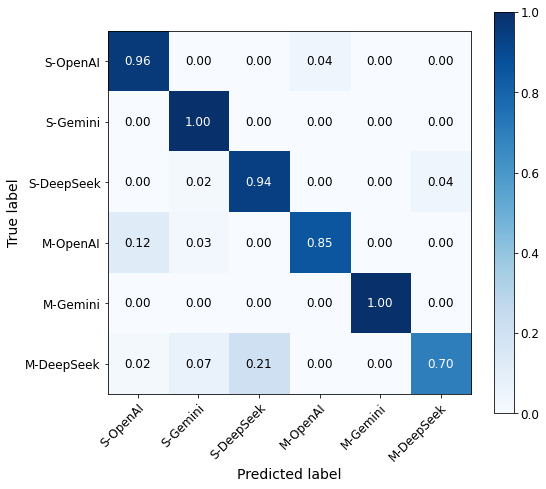

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(
    y_true,
    y_pred,
    class_names,
    normalize=True,
    save_path="confusion_matrix.pdf"
):
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    else:
        cm_norm = cm

    fig, ax = plt.subplots(figsize=(8, 7))

    # ---- plot ----
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')

    # ---- colorbar ----
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=12)

    # ---- ticks ----
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel='True label',
        xlabel='Predicted label'
    )

    # rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # ---- font sizes ----
    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)
    ax.tick_params(axis='both', which='major', labelsize=12)

    # ---- annotate cells (ONLY normalized values) ----
    thresh = cm_norm.max() / 2.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if normalize:
                text = f"{cm_norm[i, j]:.2f}"
            else:
                text = f"{cm[i, j]}"

            ax.text(
                j, i, text,
                ha="center", va="center",
                color="white" if cm_norm[i, j] > thresh else "black",
                fontsize=12  # slightly larger for readability
            )

    # ---- layout ----
    fig.tight_layout()

    # ---- save ----
    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    plt.savefig(save_path.replace(".pdf", ".png"), dpi=300, bbox_inches="tight")

    plt.show()


# ---- usage ----
class_names = [
    "S-OpenAI", "S-Gemini", "S-DeepSeek",
    "M-OpenAI", "M-Gemini", "M-DeepSeek"
]

plot_confusion_matrix(y_test, pred, class_names)